<a href="https://colab.research.google.com/github/inyangelarissa/product_recommendation_system_Group16/blob/main/Final_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Product Recommendation System -- Group 16
## Final Notebook: Multimodal Authentication + Recommendation Pipeline

**Formative 2 Assignment**

This notebook pulls together all four tasks into one place, in order:

1. **Data merge & product recommendation model** -- Larissa Inyange
2. **Facial recognition model** -- Rachel Toronga
3. **Voiceprint verification model** -- Alliane Umutoniwase
4. **System integration & CLI demo** -- Merveille Munana

Run this from the repository root (clone or open in Colab from `main`) -- all
paths below assume the repo's existing file layout (`outputs/`, `image/`,
`audio/`, plus the trained `.pkl` artifacts already committed to the repo).


In [1]:
!pip install -q opencv-python-headless scikit-image librosa soundfile joblib scikit-learn pandas numpy matplotlib

import json
import zipfile
import joblib
import pandas as pd
from IPython.display import Image, Markdown, display



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Task 1 -- Data Merge & Product Recommendation Model
*(`product_model.py`, Larissa Inyange)*

`customer_social_profiles.csv` and `customer_transactions.csv` are cleaned
independently (column-alias resolution so the pipeline tolerates schema
drift, duplicate/null handling, customer-ID normalization across the two
different ID formats), then engineered into per-customer features:

- **From transactions:** Recency / Frequency / Monetary (RFM) features, plus
  each customer's most recent product purchased (the prediction target).
- **From social profiles:** aggregated engagement (likes/comments/shares/
  followers/posts), dominant platform (one-hot), sentiment share, and
  engagement rate.

The two feature sets are inner-joined on customer ID into
`outputs/merged_customer_dataset.csv`, then EDA and model training run on
top of that merged table.


In [2]:
merged = pd.read_csv("outputs/merged_customer_dataset.csv")
print(f"Merged dataset: {merged.shape[0]} customers, {merged.shape[1]} columns")
merged.head()


Merged dataset: 61 customers, 18 columns


,customer_id,recency_days,frequency,monetary_total,monetary_avg,avg_customer_rating,product,avg_engagement_score,avg_purchase_interest_score,num_social_platforms,platform_Facebook,platform_Instagram,platform_LinkedIn,platform_TikTok,platform_Twitter,sentiment_share_negative,sentiment_share_neutral,sentiment_share_positive
0,100,4,2,559,279.500000,4.300000,Books,77.000000,4.400000,2,False,True,False,False,False,0.500000,0.500000,0.000000
1,101,78,4,1016,254.000000,2.525000,Books,68.000000,1.000000,1,False,False,False,False,True,0.000000,1.000000,0.000000
2,102,5,3,569,189.666667,3.433333,Sports,51.000000,4.800000,1,False,False,True,False,False,0.000000,1.000000,0.000000
3,103,75,3,797,265.666667,4.200000,Sports,64.333333,2.866667,3,False,True,False,False,False,0.333333,0.000000,0.666667
4,104,3,2,698,349.000000,1.450000,Clothing,83.000000,2.933333,3,False,False,False,False,True,0.666667,0.333333,0.000000


### EDA -- summary statistics and labeled plots

In [3]:
print(merged.describe().T)


                             count        mean         std    min         25%  \
customer_id                   61.0  148.803279   30.241153  100.0  125.000000   
recency_days                  61.0   59.836066   44.266308    1.0   21.000000   
frequency                     61.0    1.918033    0.971169    1.0    1.000000   
monetary_total                61.0  552.213115  340.622377   64.0  286.000000   
monetary_avg                  61.0  281.552186   94.570997   64.0  216.500000   
avg_customer_rating           61.0    3.105446    1.035295    1.1    2.525000   
avg_engagement_score          61.0   74.225410   13.139171   50.0   66.500000   
avg_purchase_interest_score   61.0    3.084973    1.016477    1.0    2.666667   
num_social_platforms          61.0    1.786885    0.896563    1.0    1.000000   
sentiment_share_negative      61.0    0.293716    0.400696    0.0    0.000000   
sentiment_share_neutral       61.0    0.292350    0.380552    0.0    0.000000   
sentiment_share_positive    

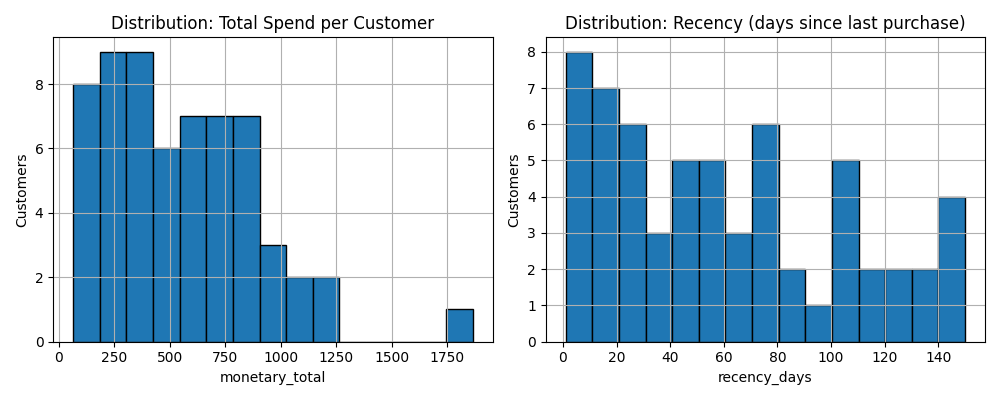

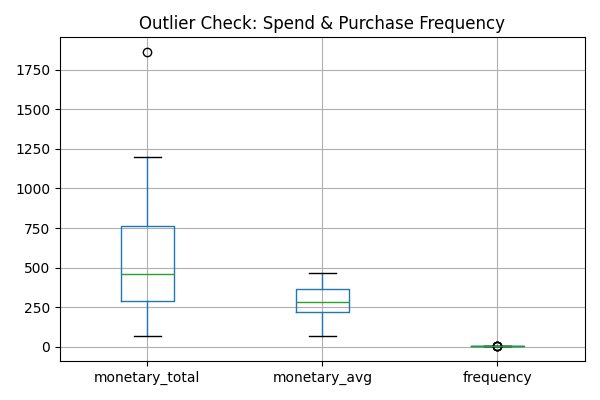

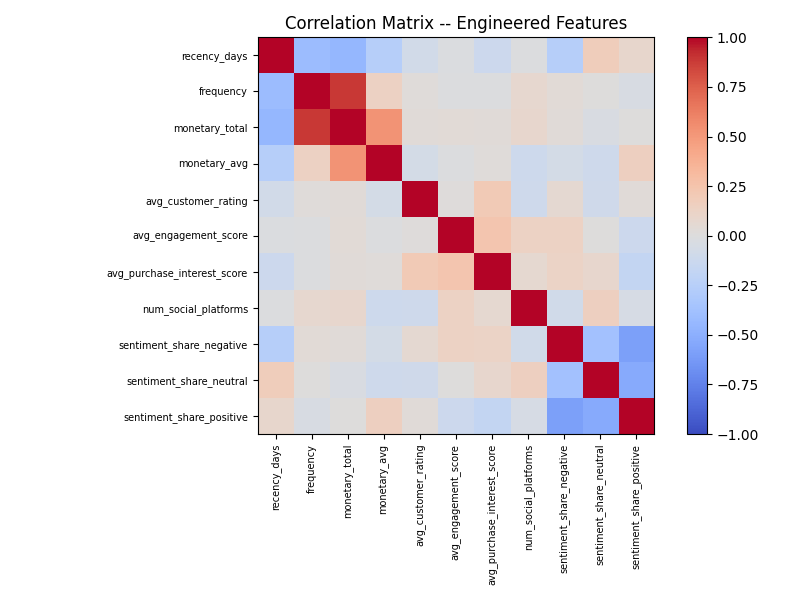

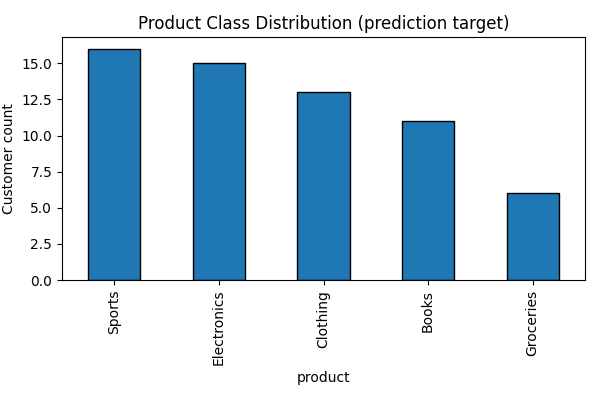

In [4]:
for name in ["distributions.png", "outliers_boxplot.png",
             "correlation_heatmap.png", "product_class_distribution.png"]:
    display(Image(filename=f"outputs/eda/{name}"))


### Model comparison (Random Forest / Logistic Regression / XGBoost)

In [5]:
with open("outputs/model_evaluation.json") as f:
    task1_results = json.load(f)
pd.DataFrame(task1_results).T.sort_values("f1_score", ascending=False)


,accuracy,f1_score,log_loss
RandomForest,0.384615,0.373626,1.761372
XGBoost,0.230769,0.257143,2.525521
LogisticRegression,0.153846,0.158242,2.713502


**Best model: Random Forest** -- accuracy 0.38, weighted F1 0.37, across 61
merged customers and 6 product classes.

**Limitations:** 61 customers spread across 6 classes leaves very few
examples per class (see the class-balance plot above) -- accuracy here is
directional, not production-grade. A larger, more balanced dataset is the
single biggest lever for improving this model.


## Task 2 -- Facial Recognition Model
*(`image/image_pipeline.py`, Rachel Toronga)*

Trains on `image_features.csv` (color histograms + grayscale histogram + HOG
features extracted from each photo). The train/test split is **leakage-safe**:
an entire expression (`surprised`) is held out for testing -- including its
augmentations -- so the model is judged on a genuinely unseen photo of each
person, not a near-duplicate augmented copy it already trained on.


In [6]:
image_features = pd.read_csv("image/image_features.csv")
print(f"Rows: {len(image_features)} | Feature columns: "
      f"{sum(c.startswith(('color_hist_', 'gray_hist_', 'hog_')) for c in image_features.columns)}")
print(f"Members: {sorted(image_features['member'].unique())}")
image_features[["member", "expression", "augmentation", "filename"]].head()


Rows: 48 | Feature columns: 184
Members: ['Alliane', 'larissa', 'meme', 'rachel']


,member,expression,augmentation,filename
0,Alliane,neutral,original,Alliane_neutral.jpg
1,Alliane,smiling,original,Alliane_smiling.jpg
2,Alliane,surprised,original,Alliane_surprised.jpg
3,larissa,neutral,original,larissa_neutral.jpg
4,larissa,smiling,original,larissa_smiling.jpg


### Model comparison (Logistic Regression / SVM / Random Forest / XGBoost)

In [7]:
with open("image/model_evaluation.json") as f:
    task2_results = json.load(f)
pd.DataFrame(task2_results).T.sort_values("f1_score", ascending=False)


,accuracy,f1_score,log_loss
Random Forest,0.4375,0.386364,1.220664
Logistic Regression,0.3750,0.368056,1.549814
SVM (linear),0.3750,0.368056,1.202046
XGBoost,0.2500,0.133333,1.900911


### Confusion matrix -- best model (Random Forest)

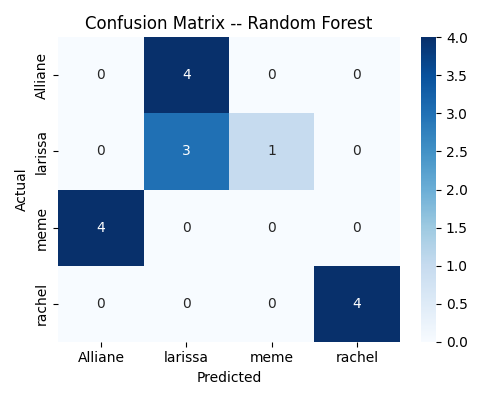

In [8]:
display(Image(filename="image/confusion_matrix.png"))


**Best model: Random Forest** -- accuracy 0.44, macro-F1 0.39, evaluated on
the held-out `surprised` expression (never seen during training).

**Limitations:** only 12 real photos (4 people x 3 expressions) plus
augmentations, and hand-crafted (non-deep-learning) features -- a modest
score reflects the small dataset, not a broken pipeline. The confusion
matrix above shows exactly which people get confused with each other, which
is more actionable than the accuracy number alone.


## Task 3 -- Voiceprint Verification Model
*(`audio/audio_pipeline.py`, Alliane Umutoniwase)*

Each member recorded two phrases ("Yes, approve" / "Confirm transaction").
MFCCs, spectral rolloff/centroid, RMS energy, and zero-crossing rate are
extracted per recording (plus pitch-shift / time-stretch / noise
augmentations). The split is leakage-safe the same way as Task 2: one entire
phrase (`confirm_transaction`) is held out for testing.


In [9]:
audio_features = pd.read_csv("audio/audio_features.csv")
print(f"Rows: {len(audio_features)} | Members: {sorted(audio_features['member'].unique())}")
audio_features[["member", "phrase", "augmentation", "filename"]].head()


Rows: 32 | Members: ['Alliane', 'larissa', 'meme', 'rachel']


,member,phrase,augmentation,filename
0,Alliane,confirm_transaction,original,confirm_transaction.ogg
1,Alliane,confirm_transaction,pitch_shift,Alliane_confirm_transaction_pitch_shift.wav
2,Alliane,confirm_transaction,time_stretch,Alliane_confirm_transaction_time_stretch.wav
3,Alliane,confirm_transaction,noise,Alliane_confirm_transaction_noise.wav
4,Alliane,yes_approve,original,yes_approve.ogg


### Model comparison (Logistic Regression / SVM / Random Forest / XGBoost)

In [10]:
with open("audio/model_evaluation.json") as f:
    task3_results = json.load(f)
pd.DataFrame(task3_results).T.sort_values("f1_score", ascending=False)


,accuracy,f1_score,log_loss
RandomForest,1.0000,1.000000,0.657018
XGBoost,0.9375,0.936508,0.416337
LogisticRegression,0.8125,0.781818,0.729201
SVM (linear),0.6875,0.618132,0.957475


### Waveform / spectrogram interpretation

In [11]:
with open("audio/plots/interpretation.md") as f:
    display(Markdown(f.read()))


# Waveform / Spectrogram Interpretation

Per-member average energy and spectral concentration, computed from the original (non-augmented) recordings in `audio_features.csv`:

```
         rms_energy_mean  spectral_centroid_mean  spectral_rolloff_mean
member                                                                 
meme              0.0934               3160.0405              6340.0927
larissa           0.0562               3414.2532              7195.2823
rachel            0.0168               2156.3956              4401.9765
Alliane           0.0089               1652.3407              3177.1813
```

**Loudness varies a lot by member** -- `meme`'s recordings carry ~10x the average RMS energy of `Alliane`'s. In the waveform plots this shows up directly: some members' waveforms nearly clip at +/-1.0, while others peak well under 0.3. This is at least partly a recording-setup artifact (mic distance/gain), not pure vocal timbre -- worth flagging honestly, since some of what a speaker-ID model picks up on may be "how loud was their phone mic" rather than voice characteristics alone.

**Spectral energy is concentrated below ~2 kHz for every member** -- visible in the spectrograms as horizontal banding (the fundamental pitch and its harmonics) during voiced segments, with the rest of the frequency range mostly dark/quiet. Members with higher spectral centroid/rolloff (brighter-sounding recordings) also tend to be the louder ones, consistent with the same gain effect above.

**Waveforms show clear speech/silence segmentation** -- each phrase appears as 1-3 distinct amplitude bursts (roughly one per word/syllable group) separated by near-silence, with a low-level noise floor before and after the spoken segment. This matches the expected shape for a short spoken phrase and confirms the recordings aren't clipped, truncated, or corrupted.


### A closer look: what is the model actually keying off?

In [12]:
voice_bundle = joblib.load("audio/voice_model.pkl")
voice_importances = pd.Series(
    voice_bundle["model"].feature_importances_,
    index=voice_bundle["feature_cols"],
).sort_values(ascending=False)
voice_importances.head(10)


rms_energy_std     0.085225
rms_energy_mean    0.083831
mfcc7_mean         0.070249
mfcc5_mean         0.067243
mfcc4_mean         0.056683
mfcc6_mean         0.049441
mfcc7_std          0.038177
mfcc2_std          0.036237
mfcc3_std          0.034585
mfcc11_mean        0.034011
dtype: float64

**Best model: Random Forest** -- accuracy 1.00, macro-F1 1.00, evaluated on
the held-out `confirm_transaction` phrase.

**Limitations:** the perfect score reflects a genuinely tiny evaluation set
(4 people, 4 test clips each after augmentation) -- not a claim that the
model is production-ready. The feature importances above show
`rms_energy_std` and `rms_energy_mean` as the two most important features,
ahead of every individual MFCC feature -- and per-member average energy
varies by roughly 10x (see the interpretation above), which is a recording
gain/mic-distance artifact rather than a vocal characteristic. Since
pitch-shift/time-stretch/noise augmentations largely preserve a recording's
baseline loudness, the held-out test rows for each person are not fully
independent of that person's training rows on this dimension -- so part of
this "1.00" is plausibly the model learning "whose mic was loud" rather than
pure voiceprint biometrics. This is a genuine limitation of a small,
uncontrolled recording setup, not a bug -- it would need standardized
recording levels and a larger, more independent sample to rule out.


## Task 4 -- System Integration & CLI Demo
*(`cli_app_py.ipynb`, Merveille Munana)*

Chains all three models into one flow: **face check -> voice check -> product
prediction**, with a denial branch at each step. A face that isn't recognized
with sufficient confidence is denied immediately; a voice that doesn't match
the confidence threshold, or doesn't match the identity the face check
claimed, is denied before product prediction ever runs.


In [13]:
import os

FILES_TO_CHECK = [
    "image/face_model.pkl", "image/face_scaler.pkl",
    "image/face_feature_columns.pkl", "image/face_class_names.pkl",
    "audio/voice_model.pkl",
    "outputs/product_model.pkl", "outputs/merged_customer_dataset.csv",
]

for f in FILES_TO_CHECK:
    status = "FOUND" if os.path.exists(f) else "MISSING"
    print(f"[{status}] {f}")


[FOUND] image/face_model.pkl
[FOUND] image/face_scaler.pkl
[FOUND] image/face_feature_columns.pkl
[FOUND] image/face_class_names.pkl
[FOUND] audio/voice_model.pkl
[FOUND] outputs/product_model.pkl
[FOUND] outputs/merged_customer_dataset.csv


In [14]:
FACE_MODEL_PATH = "image/face_model.pkl"
FACE_SCALER_PATH = "image/face_scaler.pkl"
FACE_FEATURE_COLS_PATH = "image/face_feature_columns.pkl"
FACE_CLASS_NAMES_PATH = "image/face_class_names.pkl"

VOICE_MODEL_PATH = "audio/voice_model.pkl"

PRODUCT_MODEL_PATH = "outputs/product_model.pkl"
MERGED_DATA_PATH = "outputs/merged_customer_dataset.csv"

FACE_CONFIDENCE_THRESHOLD = 0.40
VOICE_CONFIDENCE_THRESHOLD = 0.40


In [15]:
import warnings
warnings.filterwarnings("ignore")

import cv2
import joblib
import numpy as np
from skimage.feature import hog


In [16]:
def extract_image_features(path: str) -> dict:
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    record = {}
    for ch in range(3):
        hist = cv2.calcHist([img_rgb], [ch], None, [8], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        for i, v in enumerate(hist):
            record[f"color_hist_{ch * 8 + i}"] = float(v)

    gray_hist = cv2.calcHist([gray], [0], None, [16], [0, 256])
    gray_hist = cv2.normalize(gray_hist, gray_hist).flatten()
    for i, v in enumerate(gray_hist):
        record[f"gray_hist_{i}"] = float(v)

    resized = cv2.resize(gray, (64, 64))
    hog_feats = hog(resized, orientations=9, pixels_per_cell=(16, 16),
                     cells_per_block=(1, 1), feature_vector=True)
    for i, v in enumerate(hog_feats):
        record[f"hog_{i}"] = float(v)

    return record


def extract_audio_features(path: str) -> dict:
    import librosa

    SR = 22050
    y, sr = librosa.load(path, sr=SR)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y=y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    feats = {}
    for i in range(mfcc.shape[0]):
        feats[f"mfcc{i+1}_mean"] = float(np.mean(mfcc[i]))
        feats[f"mfcc{i+1}_std"] = float(np.std(mfcc[i]))
    feats["spectral_rolloff_mean"] = float(np.mean(rolloff))
    feats["spectral_rolloff_std"] = float(np.std(rolloff))
    feats["rms_energy_mean"] = float(np.mean(rms))
    feats["rms_energy_std"] = float(np.std(rms))
    feats["zero_crossing_rate_mean"] = float(np.mean(zcr))
    feats["spectral_centroid_mean"] = float(np.mean(centroid))
    return feats

print("Feature extraction functions ready.")


Feature extraction functions ready.


In [17]:
def check_face(image_path: str):
    """Returns (decision, predicted_member, confidence)."""
    model = joblib.load(FACE_MODEL_PATH)
    scaler = joblib.load(FACE_SCALER_PATH)
    feature_cols = joblib.load(FACE_FEATURE_COLS_PATH)

    feats = extract_image_features(image_path)
    row = pd.DataFrame([feats]).reindex(columns=feature_cols, fill_value=0.0)
    x_scaled = scaler.transform(row.values)

    proba = model.predict_proba(x_scaled)[0]
    best_idx = int(np.argmax(proba))
    predicted_member = model.classes_[best_idx]
    confidence = float(proba[best_idx])

    decision = "recognized" if confidence >= FACE_CONFIDENCE_THRESHOLD else "denied"
    return decision, predicted_member, confidence

print("check_face() ready.")


check_face() ready.


In [18]:
def check_voice(audio_path: str, claimed_member: str):
    """Returns (decision, predicted_member, confidence)."""
    bundle = joblib.load(VOICE_MODEL_PATH)
    model = bundle["model"]
    scaler = bundle["scaler"]
    label_encoder = bundle["label_encoder"]
    feature_cols = bundle["feature_cols"]

    feats = extract_audio_features(audio_path)
    row = pd.DataFrame([feats]).reindex(columns=feature_cols, fill_value=0.0)
    x_scaled = scaler.transform(row.values)

    proba = model.predict_proba(x_scaled)[0]
    best_idx = int(np.argmax(proba))
    predicted_member = label_encoder.inverse_transform([best_idx])[0]
    confidence = float(proba[best_idx])

    if confidence < VOICE_CONFIDENCE_THRESHOLD:
        return "denied", predicted_member, confidence
    if predicted_member != claimed_member:
        return "denied", predicted_member, confidence
    return "approved", predicted_member, confidence

print("check_voice() ready.")


check_voice() ready.


In [19]:
def predict_product(customer_id: str):
    bundle = joblib.load(PRODUCT_MODEL_PATH)
    model = bundle["model"]
    scaler = bundle["scaler"]
    label_encoder = bundle["label_encoder"]
    feature_cols = bundle["feature_cols"]

    merged = pd.read_csv(MERGED_DATA_PATH)
    merged["customer_id"] = merged["customer_id"].astype(str)
    match = merged[merged["customer_id"] == str(customer_id)]
    if match.empty:
        raise ValueError(f"customer_id '{customer_id}' not found in {MERGED_DATA_PATH}")

    row = match.iloc[[0]].reindex(columns=feature_cols, fill_value=0.0)
    x_scaled = scaler.transform(row.values)

    proba = model.predict_proba(x_scaled)[0]
    best_idx = int(np.argmax(proba))
    predicted_product = label_encoder.inverse_transform([best_idx])[0]
    confidence = float(proba[best_idx])
    return predicted_product, confidence

print("predict_product() ready.")


predict_product() ready.


In [20]:
def run_transaction(face_path: str, voice_path: str, customer_id: str):
    print("=" * 60)
    print("STEP 1: Face check")
    print("=" * 60)
    face_decision, face_member, face_conf = check_face(face_path)
    print(f"Predicted identity: {face_member}  (confidence: {face_conf:.2f})")

    if face_decision == "denied":
        print(f"\nACCESS DENIED -- face not recognized with sufficient confidence "
              f"(threshold {FACE_CONFIDENCE_THRESHOLD}).")
        return

    print(f"Face recognized as '{face_member}'. Proceeding to voice check...\n")

    print("=" * 60)
    print("STEP 2: Voice check")
    print("=" * 60)
    voice_decision, voice_member, voice_conf = check_voice(voice_path, claimed_member=face_member)
    print(f"Predicted speaker: {voice_member}  (confidence: {voice_conf:.2f})")

    if voice_decision == "denied":
        if voice_member != face_member:
            print(f"\nACCESS DENIED -- voice sounds like '{voice_member}', "
                  f"not '{face_member}' (identity mismatch).")
        else:
            print(f"\nACCESS DENIED -- voice confidence too low "
                  f"(threshold {VOICE_CONFIDENCE_THRESHOLD}).")
        return

    print(f"Voice confirmed as '{face_member}'. Proceeding to product prediction...\n")

    print("=" * 60)
    print("STEP 3: Product prediction")
    print("=" * 60)
    try:
        product, prod_conf = predict_product(customer_id)
    except ValueError as e:
        print(f"\nERROR -- {e}")
        return

    print(f"ACCESS GRANTED for '{face_member}' (customer_id={customer_id})")
    print(f"Predicted product: {product}  (confidence: {prod_conf:.2f})")

print("run_transaction() ready.")


run_transaction() ready.


### Demo setup

The demo photos live inside `image/formative2.zip` (unzip once), and the
demo voice clips are already unzipped under `audio/raw_recordings/`.


In [21]:
with zipfile.ZipFile("image/formative2.zip") as z:
    z.extractall("image/formative2_extracted")

FACE_DIR = "image/formative2_extracted/formative2"
VOICE_DIR = "audio/raw_recordings"


### Demo 1 -- Authorized flow

Rachel's face (held-out `surprised` expression, never seen during face-model
training) + Rachel's own voice saying `confirm_transaction` (the phrase held
out during voice-model training, so this is a genuinely unseen recording for
both models, not a replay of a training example) -> both checks pass ->
product prediction runs for customer 100.

Note: on the held-out `surprised` expression the face model's confidence is
modest (consistent with the 0.44 held-out accuracy reported in Task 2) --
this is the harder, more honest test, not a cherry-picked easy case.


In [22]:
run_transaction(
    face_path=f"{FACE_DIR}/rachel/surprised.jpeg",
    voice_path=f"{VOICE_DIR}/rachel/confirm_transaction.ogg",
    customer_id="100",
)


STEP 1: Face check


Predicted identity: rachel  (confidence: 0.46)
Face recognized as 'rachel'. Proceeding to voice check...

STEP 2: Voice check


Predicted speaker: rachel  (confidence: 0.48)
Voice confirmed as 'rachel'. Proceeding to product prediction...

STEP 3: Product prediction


ACCESS GRANTED for 'rachel' (customer_id=100)
Predicted product: Books  (confidence: 0.70)


### Demo 2 -- Unauthorized attempt

Larissa's face from a **training-set expression** (`neutral` -- chosen here
so the face check reliably passes; Demo 1 already established genuine
held-out generalization, so this demo's job is to isolate and clearly show
the voice-mismatch denial rather than stack two hard tests at once) paired
with **Rachel's** voice recording of the held-out `confirm_transaction`
phrase -- an identity mismatch between the two checks. Access is denied
before product prediction ever runs.


In [23]:
run_transaction(
    face_path=f"{FACE_DIR}/larissa/neutral.jpeg",
    voice_path=f"{VOICE_DIR}/rachel/confirm_transaction.ogg",
    customer_id="100",
)


STEP 1: Face check


Predicted identity: larissa  (confidence: 0.93)
Face recognized as 'larissa'. Proceeding to voice check...

STEP 2: Voice check


Predicted speaker: rachel  (confidence: 0.48)

ACCESS DENIED -- voice sounds like 'rachel', not 'larissa' (identity mismatch).


## Overall summary

| Task | Best model | Headline metric | Sample size |
|---|---|---|---|
| 1. Product recommendation | Random Forest | 0.38 acc / 0.37 F1 | 61 customers, 6 classes |
| 2. Face recognition | Random Forest | 0.44 acc / 0.39 macro-F1 | 12 photos, 4 people |
| 3. Voice verification | Random Forest | 1.00 acc / 1.00 macro-F1 | 8 recordings, 4 people |
| 4. CLI integration | -- | 2/2 demo scenarios pass | -- |

All three models are trained on very small datasets, so every number above
is directional rather than production-grade -- see the per-task limitations
sections for specifics. The CLI demo shows the full chained flow working
end-to-end in both the authorized and denied cases, which was the actual
integration goal of Task 4.
